# SE Tree-Based — Hyperparameter Tuning

In [4]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *
sns.set_palette('Blues');plt.rcParams['axes.prop_cycle']=plt.cycler(color=plt.cm.Blues(np.linspace(0.3,0.9,8)))
import warnings;warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('../../datasets/augmented_data.csv');X=df.drop('diagnosis',axis=1);y=df['diagnosis']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
sc=StandardScaler();X_tr=sc.fit_transform(X_train);X_te=sc.transform(X_test)

In [6]:
bl = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('et', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
]
gs = GridSearchCV(
    StackingClassifier(estimators=bl, final_estimator=LogisticRegression(random_state=42), cv=5),
    {'final_estimator__C': [0.1, 1, 10]},
    cv=3,
    scoring='accuracy'
)
gs.fit(X_train, y_train)
print(f"Best: {gs.best_params_}, Score: {gs.best_score_:.4f}")
m = gs.best_estimator_
y_pred = m.predict(X_test)
y_proba = m.predict_proba(X_test)[:, 1]

Best: {'final_estimator__C': 0.1}, Score: 0.9750


In [7]:
acc=accuracy_score(y_test,y_pred);prec=precision_score(y_test,y_pred);rec=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred);cm=confusion_matrix(y_test,y_pred);tn,fp,fn,tp=cm.ravel()
spec=tn/(tn+fp);auc=roc_auc_score(y_test,y_proba)
print(f"Acc:{acc:.4f} Prec:{prec:.4f} Rec:{rec:.4f} F1:{f1:.4f} Spec:{spec:.4f} AUC:{auc:.4f}\nCM:\n{cm}")

Acc:0.9750 Prec:1.0000 Rec:0.9500 F1:0.9744 Spec:1.0000 AUC:0.9969
CM:
[[100   0]
 [  5  95]]


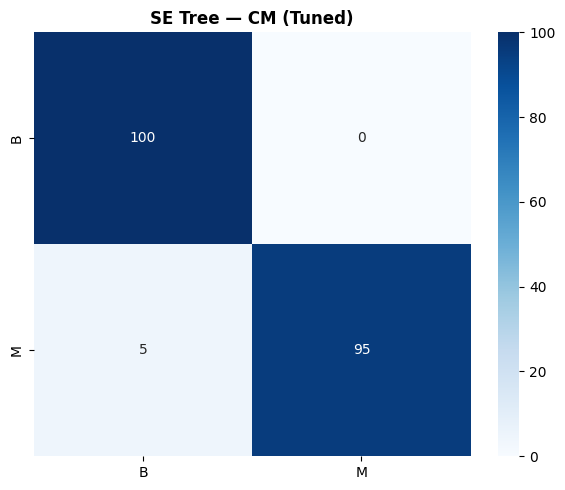

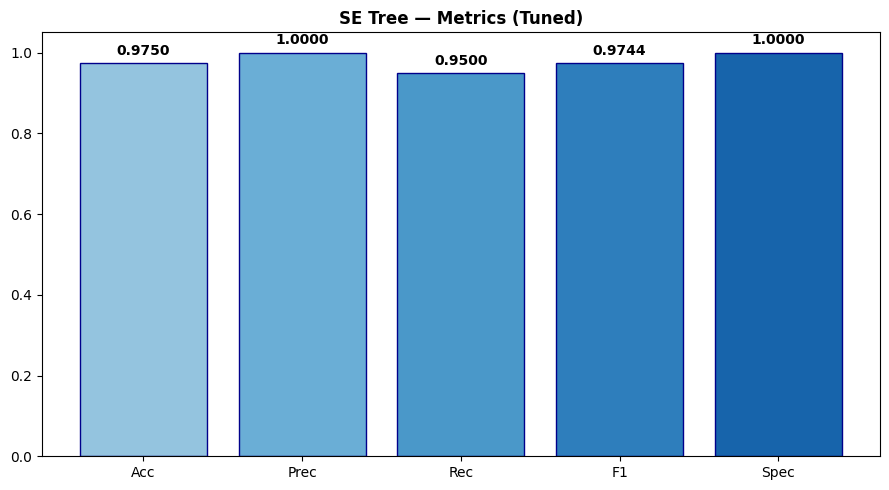

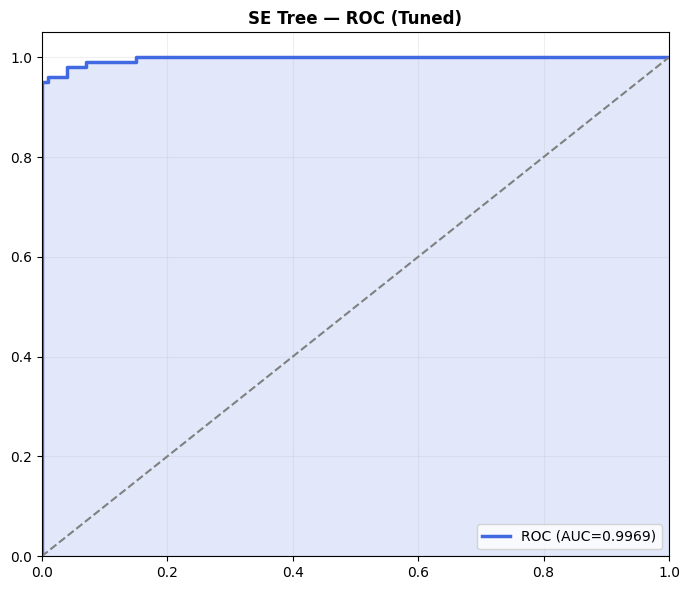

In [8]:
plt.figure(figsize=(6,5));sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['B','M'],yticklabels=['B','M'])
plt.title('SE Tree — CM (Tuned)',fontweight='bold');plt.tight_layout();plt.show()
n=['Acc','Prec','Rec','F1','Spec'];v=[acc,prec,rec,f1,spec];c=plt.cm.Blues([0.4,0.5,0.6,0.7,0.8])
plt.figure(figsize=(9,5));bars=plt.bar(n,v,color=c,edgecolor='darkblue')
plt.ylim(0,1.05);plt.title('SE Tree — Metrics (Tuned)',fontweight='bold')
for b,v in zip(bars,v):plt.text(b.get_x()+b.get_width()/2,b.get_height()+0.02,f'{v:.4f}',ha='center',fontweight='bold')
plt.tight_layout();plt.show()
fpr,tpr,_=roc_curve(y_test,y_proba)
plt.figure(figsize=(7,6));plt.plot(fpr,tpr,'royalblue',lw=2.5,label=f'ROC (AUC={auc:.4f})')
plt.fill_between(fpr,tpr,alpha=0.15,color='royalblue');plt.plot([0,1],[0,1],'gray',ls='--')
plt.xlim(0,1);plt.ylim(0,1.05);plt.title('SE Tree — ROC (Tuned)',fontweight='bold')
plt.legend();plt.grid(alpha=0.2);plt.tight_layout();plt.show()